In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv(r"C:\Users\sanja\Downloads\wine_fraud (1).csv")

In [7]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,Legit,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,Legit,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,Legit,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,Legit,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,Legit,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,Legit,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,Legit,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,Legit,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,Legit,white


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   object 
 12  type                  6497 non-null   object 
dtypes: float64(11), object(2)
memory usage: 660.0+ KB


In [9]:
df['type'].unique()

array(['red', 'white'], dtype=object)

In [10]:
df['quality'].unique()

array(['Legit', 'Fraud'], dtype=object)

In [11]:
df['quality'].value_counts()

quality
Legit    6251
Fraud     246
Name: count, dtype: int64

In [12]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

In [13]:
df.duplicated().sum()


np.int64(1177)

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000
mean,7.215179,0.344130,0.318494,5.048477,0.056690,30.036654,114.109023,0.994535,3.224664,0.533357,10.549241
std,1.319671,0.168248,0.147157,4.500180,0.036863,17.805045,56.774223,0.002966,0.160379,0.149743,1.185933
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000
25%,6.400000,0.230000,0.240000,1.800000,0.038000,16.000000,74.000000,0.992200,3.110000,0.430000,9.500000
50%,7.000000,0.300000,0.310000,2.700000,0.047000,28.000000,116.000000,0.994650,3.210000,0.510000,10.400000
75%,7.700000,0.410000,0.400000,7.500000,0.066000,41.000000,153.250000,0.996770,3.330000,0.600000,11.400000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000


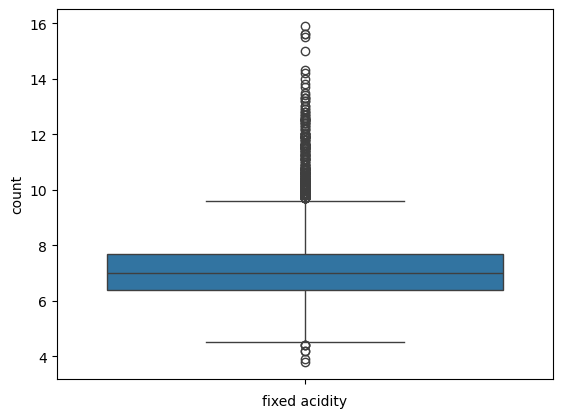

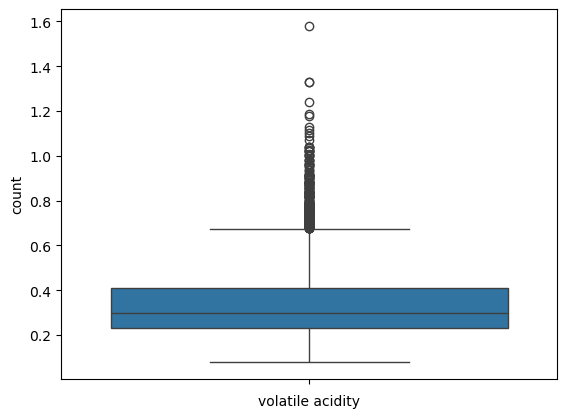

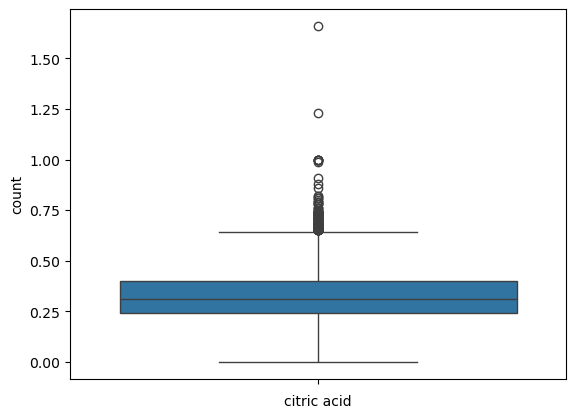

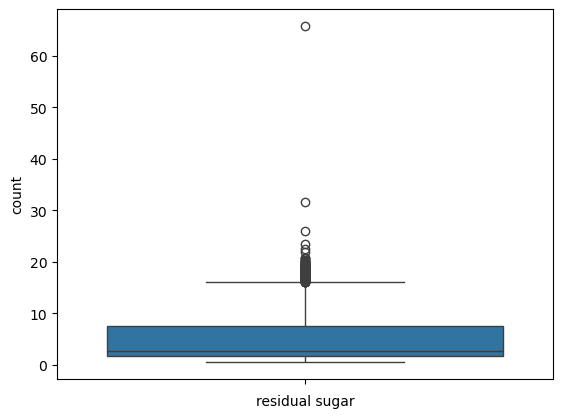

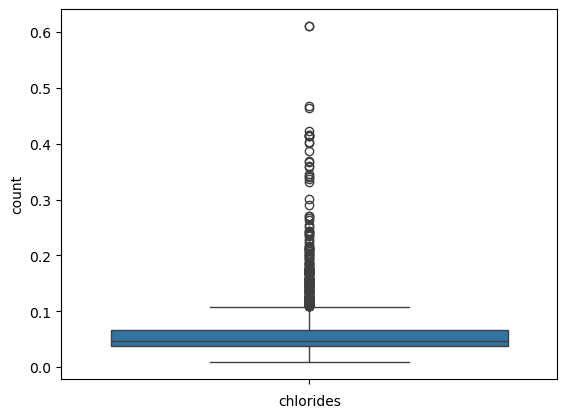

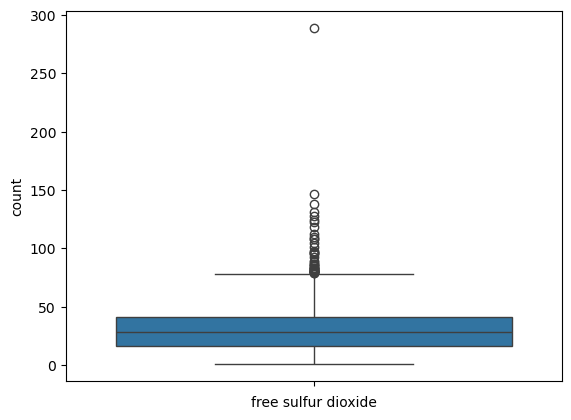

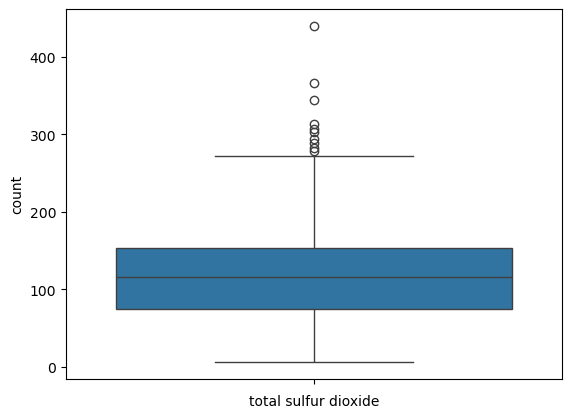

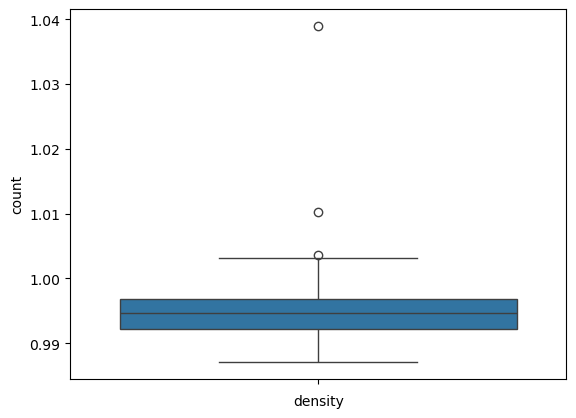

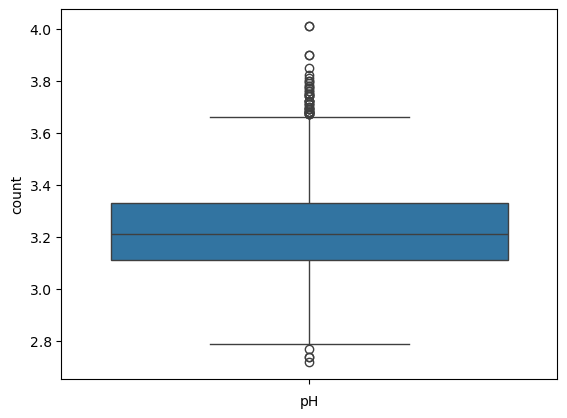

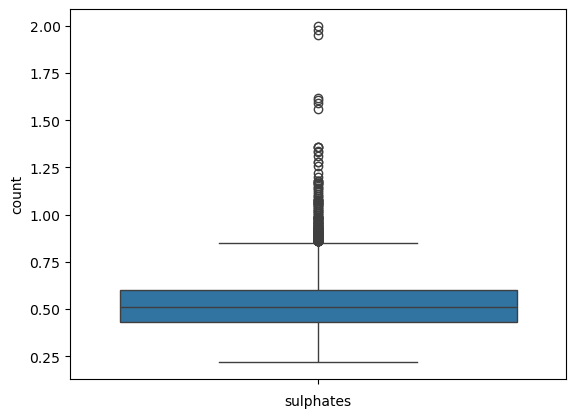

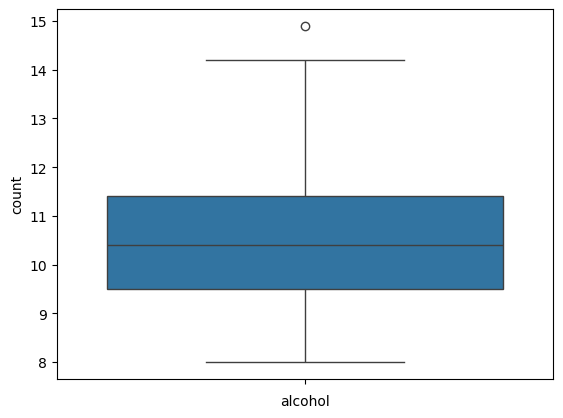

In [17]:
for x in df.columns:
    if df[x].dtype != object:
        sns.boxplot(df[x])
        plt.xlabel(x)
        plt.ylabel('count')
        plt.show()

In [18]:
for x in df.columns:
    if df[x].dtype != object:
        Q1 = df[x].quantile(0.25)
        Q3 = df[x].quantile(0.75)
        IQR = Q3-Q1
        ll = Q1-1.5*IQR
        ul = Q3+1.5*IQR
        df = df[(df[x]>=ll) & (df[x]<=ul)]

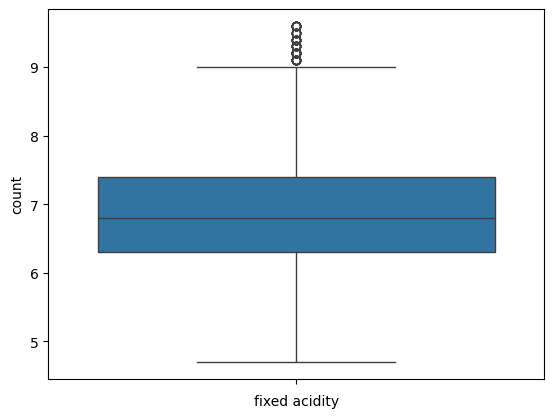

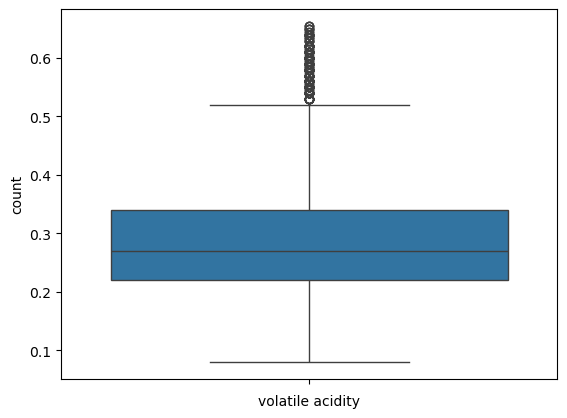

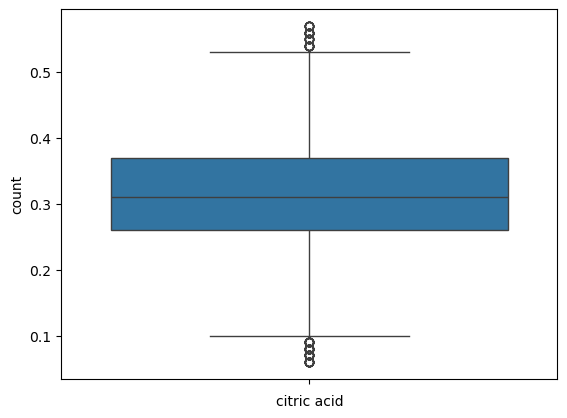

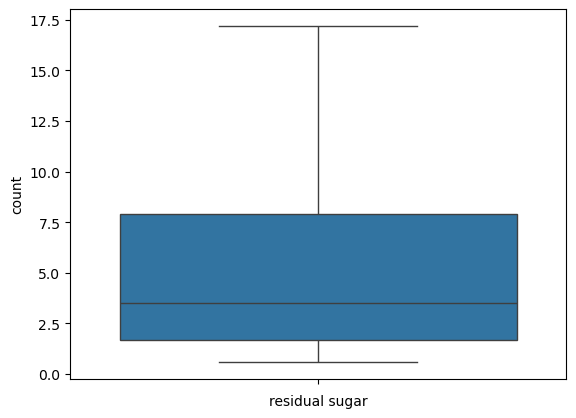

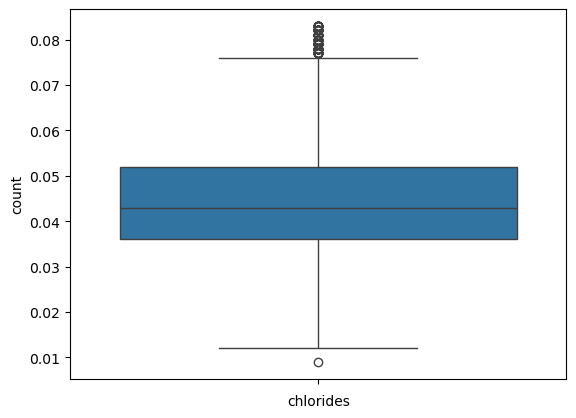

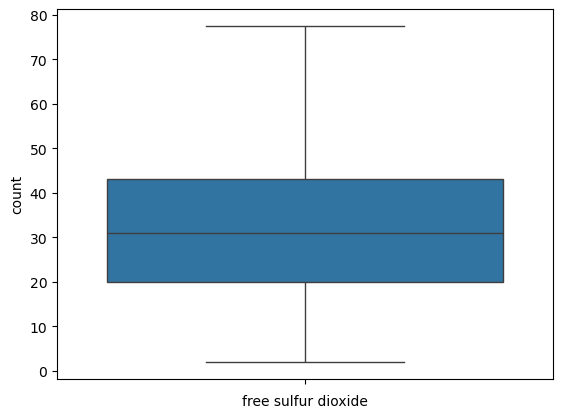

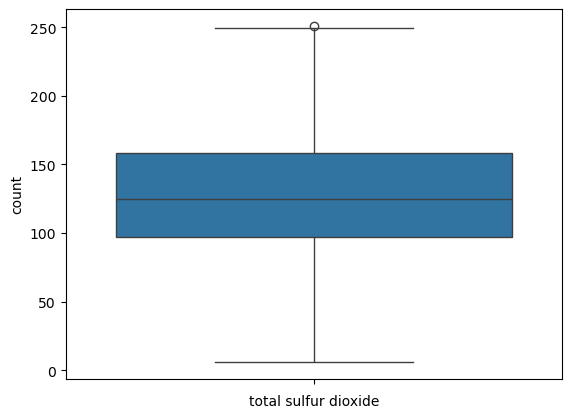

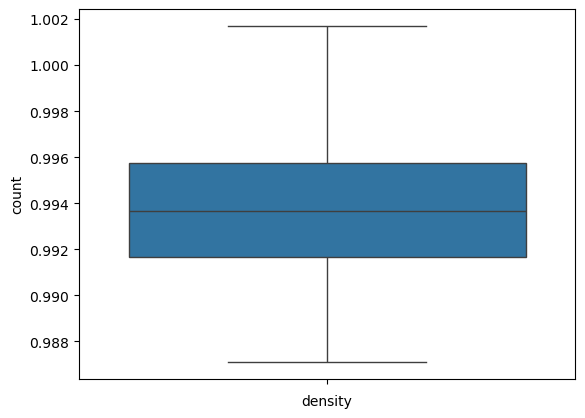

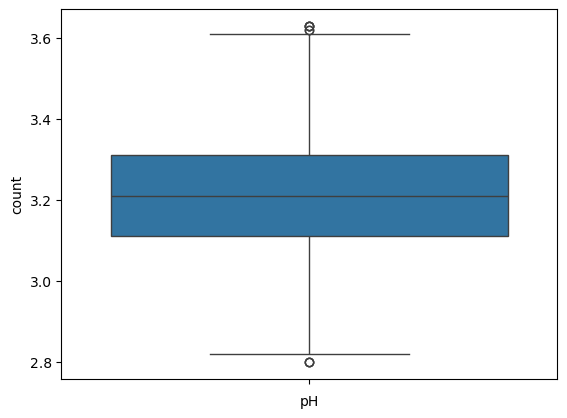

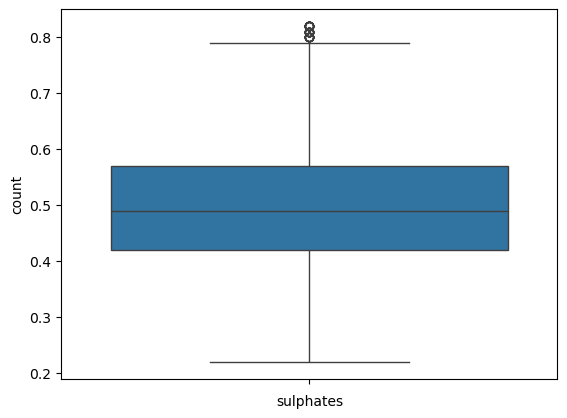

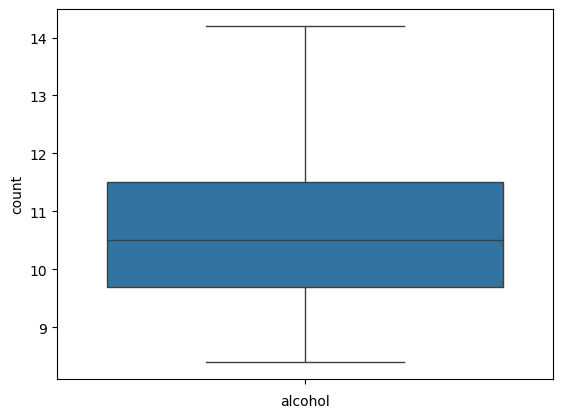

In [19]:
for x in df.columns:
    if df[x].dtype != object:
        sns.boxplot(df[x])
        plt.xlabel(x)
        plt.ylabel('count')
        plt.show()

In [20]:
from sklearn.preprocessing import LabelEncoder


In [21]:
le = LabelEncoder()
df['quality'] = le.fit_transform(df['quality'])
df['type'] = le.fit_transform(df['type'])

In [22]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.99640,3.30,0.46,9.4,1,0
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,1,0
20,8.9,0.22,0.48,1.8,0.077,29.0,60.0,0.99680,3.39,0.53,9.4,1,0
21,7.6,0.39,0.31,2.3,0.082,23.0,71.0,0.99820,3.52,0.65,9.7,1,0
25,6.3,0.39,0.16,1.4,0.080,11.0,23.0,0.99550,3.34,0.56,9.3,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,1,1
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,1,1
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,1,1
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,1,1


In [23]:
li = []
for x in df.columns:
    if x=='quality':
        continue
    li.append(x)
    

In [24]:
li

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'type']

In [25]:
X = df[li]
y = df['quality']


In [26]:
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.99640,3.30,0.46,9.4,0
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,0
20,8.9,0.22,0.48,1.8,0.077,29.0,60.0,0.99680,3.39,0.53,9.4,0
21,7.6,0.39,0.31,2.3,0.082,23.0,71.0,0.99820,3.52,0.65,9.7,0
25,6.3,0.39,0.16,1.4,0.080,11.0,23.0,0.99550,3.34,0.56,9.3,0
...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,1
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,1
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,1
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,1


In [27]:
y

6       1
9       1
20      1
21      1
25      1
       ..
6492    1
6493    1
6494    1
6495    1
6496    1
Name: quality, Length: 3812, dtype: int64

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test , y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=34)

In [29]:
X_train.shape

(3049, 12)

In [30]:
from sklearn.ensemble import RandomForestClassifier


In [31]:
model=RandomForestClassifier()
model.fit(X_train,y_train)

RandomForestClassifier()

In [32]:
y_pred=model.predict(X_test)

In [33]:
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [34]:
result = pd.DataFrame(columns=['Actual values','Predicted values'])
result['Actual values'] = y_test
result['Predicted values'] = y_pred
result['Predicted values'].value_counts()

Predicted values
1    762
0      1
Name: count, dtype: int64

In [35]:
y_test.value_counts()

quality
1    743
0     20
Name: count, dtype: int64

In [36]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9724770642201835

In [37]:
# 1 --> 743
# 0 --> 20


In [38]:
#smote - 

In [39]:
trees_li = [50,75,100,125,150]


In [41]:
for x in trees_li:
    dummy = RandomForestClassifier(n_estimators=x)
    dummy.fit(X_train,y_train)
    pred = dummy.predict(X_test)
    print("number of decision tree: ", x, 'Accuracy score:',end='')
    print(accuracy_score(pred,y_test))

number of decision tree:  50 Accuracy score:0.9737876802096985
number of decision tree:  75 Accuracy score:0.9737876802096985
number of decision tree:  100 Accuracy score:0.9737876802096985
number of decision tree:  125 Accuracy score:0.9711664482306684
number of decision tree:  150 Accuracy score:0.9737876802096985


In [42]:
# Data Imbalance : if our target column , if there class of one majority that data can be imbalance.
#it will perform very good on the data that we are using to train and test the model
#but it may be a possibility it wont work well on the new unseen data


In [43]:
#1000 -> yes
#60 ->no
#SMOTE WIIL BALANCE OUR DATA

In [44]:
#SMOTE = SYNTHETIC MINORITY OVERSAMPLING TECHNIQUE. 
# IT IA TECHNIQUE WHICH IS USED TO HANDLE THE IMBALANCE DATASET.

In [45]:
#IT IS A TECHNIQUE THAT IS USED WHEN OUR DATA HAS MORE OF ONE TYPE AND VERY FEW OF ANOTHER
#it not generate a new ranodom values in dtaset . it only generate new values based on previous patterns in the data set

In [46]:
# WE ARE BUILDING A MODEL TO DETECT FRAUD
#800 TRANSACTIONS ARE NORMAL
#50 ARE FRAUD
# IT WILL IGNORE FRAUD AND IT WILL ONLY FOCUS ON NORMAL

In [48]:
from imblearn.over_sampling import SMOTE

In [50]:
smote = SMOTE()
new_X, new_y = smote.fit_resample(X,y)

In [51]:
new_X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type
0,7.900000,0.600000,0.060000,1.600000,0.069000,15.000000,59.000000,0.996400,3.300000,0.460000,9.400000,0
1,7.500000,0.500000,0.360000,6.100000,0.071000,17.000000,102.000000,0.997800,3.350000,0.800000,10.500000,0
2,8.900000,0.220000,0.480000,1.800000,0.077000,29.000000,60.000000,0.996800,3.390000,0.530000,9.400000,0
3,7.600000,0.390000,0.310000,2.300000,0.082000,23.000000,71.000000,0.998200,3.520000,0.650000,9.700000,0
4,6.300000,0.390000,0.160000,1.400000,0.080000,11.000000,23.000000,0.995500,3.340000,0.560000,9.300000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
7369,6.608722,0.330060,0.361278,6.278496,0.051738,12.563910,165.221052,0.995933,3.233023,0.389128,8.852331,1
7370,6.102450,0.411892,0.194080,1.300000,0.038767,9.893172,72.616465,0.991811,3.385920,0.562137,10.923293,1
7371,7.116853,0.442734,0.311685,4.784149,0.042052,16.337062,175.220979,0.994733,3.280424,0.426317,9.909487,1
7372,7.743488,0.256799,0.402848,1.705519,0.039850,26.509934,115.094923,0.993319,3.285651,0.476203,10.609492,1


In [52]:
y.value_counts()

quality
1    3687
0     125
Name: count, dtype: int64

In [53]:
new_y.value_counts()

quality
1    3687
0    3687
Name: count, dtype: int64

In [54]:
new_X.duplicated().sum()

np.int64(0)

In [56]:
from sklearn.model_selection import train_test_split
X_train, X_test , y_train, y_test = train_test_split(new_X,new_y,test_size=0.2, random_state=42)

In [59]:
X_train.shape

(5899, 12)

In [60]:
final_model = RandomForestClassifier()
final_model.fit(X_train,y_train)

RandomForestClassifier()

In [61]:
y_pred = final_model.predict(X_test)

In [62]:
accuracy_score(y_pred,y_test)

0.9810169491525423